# Lab: Relationships Between Categorical Features

A fictional telecommunications company wants to understand which customer groups had the greatest observed churn percentages. A customer **churned** if they left the company during the previous month.

You will use the reproducible analysis workflow:

1. **Question:** What do we want to learn?
2. **Data:** Which observations and features can help answer it?
3. **Operation:** What should the code select, calculate, or compare?
4. **Check:** Does the result have the expected rows, columns, units, and possible values?
5. **Evidence:** Which result directly answers the question?
6. **Conclusion:** What claim is supported?
7. **Limitation:** What should we avoid concluding?


## Learning goals

By the end of this lab, you should be able to:

- identify a target feature;
- describe the distribution of a categorical target;
- create count, joint-percentage, and conditional-percentage cross-tabs;
- choose a normalization direction from the question;
- check the denominator represented by a percentage;
- refine the visual design of a categorical comparison; and
- distinguish an observed relationship from a causal claim.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook's output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Dataset

Each row represents one customer in IBM's fictional telecommunications sample.

| Feature | Feature type | Description |
| --- | --- | --- |
| `customer_id` | Identifier | Anonymous customer identifier |
| `contract` | Categorical | Month-to-month, one-year, or two-year contract |
| `internet_service` | Categorical | DSL, fiber optic, or no internet service |
| `tech_support` | Categorical | Technical-support status |
| `payment_method` | Categorical | Customer's payment method |
| `paperless_billing` | Categorical | Whether the customer uses paperless billing |
| `churn` | Categorical target | Whether the customer left during the previous month |

The file contains 7,043 customers and no missing values in these fields. See `data/README.md` for provenance and preparation.


## Prepare the notebook

Import Pandas using its conventional alias `pd` and Matplotlib's `pyplot` component using its conventional alias `plt`.


In [42]:
# Write your code here.
import pandas as pd
import matplotlib.pyplot as plt

## Read the data

Read `data/telco_customer_churn.csv` into a DataFrame named `customers`.


In [43]:
# Write your code here.
customers = pd.read_csv('data/telco_customer_churn.csv')

## Check the data

Display the first five rows.


In [44]:
# Write your code here.
customers.head()

,customer_id,contract,internet_service,tech_support,payment_method,paperless_billing,churn
0,7590-VHVEG,Month-to-month,DSL,No,Electronic check,Yes,No
1,5575-GNVDE,One year,DSL,No,Mailed check,No,No
2,3668-QPYBK,Month-to-month,DSL,No,Mailed check,Yes,Yes
3,7795-CFOCW,One year,DSL,Yes,Bank transfer (automatic),No,No
4,9237-HQITU,Month-to-month,Fiber optic,No,Electronic check,Yes,Yes


## Check the features

Display a summary that includes the feature names, non-missing counts, and Pandas data storage types.


In [45]:
# Write your code here.
customers.info()
# Count the missing values in every feature.
#
# Display the missing-value count for every feature.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        7043 non-null   object
 1   contract           7043 non-null   object
 2   internet_service   7043 non-null   object
 3   tech_support       7043 non-null   object
 4   payment_method     7043 non-null   object
 5   paperless_billing  7043 non-null   object
 6   churn              7043 non-null   object
dtypes: object(7)
memory usage: 385.3+ KB


In [46]:
# Write your code here.
customers.isnull().sum()

customer_id          0
contract             0
internet_service     0
tech_support         0
payment_method       0
paperless_billing    0
churn                0
dtype: int64

A **categorical** feature places observations into groups or labels. A **quantitative** feature records a numerical amount or measurement for which arithmetic is meaningful.


**Complete the table using the results above.** In the data type column, classify each feature as categorical or quantitative. In the data storage type column, record the type reported by Pandas. Different Pandas versions may display text as `str` or `object`.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `customer_id` | categorical | object | 0 |
| `contract` | categorical | object | 0 |
| `internet_service` | categorical | object | 0 |
| `tech_support` | categorical | object | 0 |
| `payment_method` | categorical | object | 0 |
| `paperless_billing` | categorical | object | 0 |
| `churn` | categorical | object | 0 |


## Identify the target


**Which feature is the target, and what outcome does it represent?**

Your answer: 'churn' is the target and it's telling us if a customer left the service the previous month


## Describe the target distribution with counts

Create and display a Series named `churn_counts`.


In [47]:
# Write your code here.
churn_counts = customers['churn'].value_counts()

churn_counts

churn
No     5174
Yes    1869
Name: count, dtype: int64

**Which target outcome is more frequent?**

Your answer: Customers do NOT churn more frequently than they do churn


## Describe the target distribution with relative frequencies

Create and display a Series named `churn_percent`.


In [48]:
# Write your code here.
churn_percent = customers['churn'].value_counts(normalize=True)*100

churn_percent

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

**What percentage of all customers churned?**

Your answer: The percentage of customers that churned is 26.54%


# Analysis 1: Is churn related to contract type?

Follow the analysis workflow from question through limitation.


In [49]:
customers['contract'].value_counts()

contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

**Before calculating a cross-tab, which contract type do you predict had the greatest churn percentage? Explain your prediction.**

Your answer: I think month-to-month has the greatest churn percentage. Due to the short-term design of the contract, it would be easier to cancel and find another provider, which is what most short-term customers choose that option for. Also, One Year and Two Year would be locked in until their contract ends, unable to cancel, unless they pay a likely penalty, until the year/two years is complete.


## Step 1: Question


The question is: **Is churn related to contract type?**


## Step 2: Data

The relevant features are `contract` and `churn`. Before calculating percentages, compare the raw counts in their joint distribution.

Create and display `contract_churn_counts`, with contract types in the rows and churn outcomes in the columns.

Create and display `contract_churn_counts`, with contract types in the rows and churn outcomes in the columns.


In [50]:
# Write your code here.
contract_churn_counts = pd.crosstab(customers['contract'], customers['churn'])

contract_churn_counts

churn,No,Yes
contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


**Which contract type has the greatest raw number of customers who churned?**

Your answer: Month-to-month has the greatest number of customers who've churned, at a value of 1655


**Do the raw churn counts establish which contract group was most likely to churn? Explain.**

Your answer: No. While the numbers hint that the month-to-month is most likely to churn, this can also be explained with the fact that far more customers overall are in the month-to-month contract. Without looking at the percentages of each contract type, we're unable to see if either of the other contract types have a higher percentage of churn rates.


## Step 3: Operation

To compare likelihood fairly, calculate churn percentages within each contract type. First inspect the group totals.

Recreate the contract/churn cross-tab using `margins=True`.


In [51]:
# Write your code here.
pd.crosstab(customers['contract'], customers['churn'], margins=True)

churn,No,Yes,All
contract,,,
Month-to-month,2220,1655,3875
One year,1307,166,1473
Two year,1647,48,1695
All,5174,1869,7043


**Why do the contract-group totals matter when comparing likelihood?**

Your answer: With the group totals, you're able to see how many customers are in that specific contract-type. It gives a firmer grasp of how many customers there are in total and the dispersion between the different values in a feature.


### Joint percentages

Create and display `contract_joint_percent`. All cells together should add to 100%.


In [52]:
# Write your code here.
contract_joint_percent = pd.crosstab(customers['contract'], customers['churn'], normalize=True)*100

contract_joint_percent

churn,No,Yes
contract,,
Month-to-month,31.520659,23.498509
One year,18.557433,2.356950
Two year,23.384921,0.681528


## Step 4: Check

Display the sum of every value in `contract_joint_percent`.


In [53]:
# Write your code here.
contract_joint_percent.sum().sum()

np.float64(100.0)

**What denominator does each joint percentage use?**

Your answer: The denominator is the entire dataset, making all cells add up to 100%


**Does the joint-percentage table directly answer which contract group was most likely to churn?**

Your answer: No, since it just shows the percentages overall between the contract-types. It's not completely clear how they compare against each other


### Conditional percentages

Create `churn_within_contract` so each row describes churn outcomes within one contract type.


In [54]:
# Write your code here.
churn_within_contract = pd.crosstab(customers['contract'], customers['churn'], normalize='index')*100

churn_within_contract

churn,No,Yes
contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Check the conditional percentages

Display the sum of each row in `churn_within_contract`.


In [55]:
# Write your code here.
churn_within_contract.sum(axis=1)

contract
Month-to-month    100.0
One year          100.0
Two year          100.0
dtype: float64

**What should every row add to, and why?**

Your answer: Each row should add to 100% because the denominator has changed from the complete dataset to a separate denominator for each category, in this case, the contract-type


**Which contract group had the greatest observed churn percentage? Report the percentage.**

Your answer: The group with the greatest observed churn percentage was the Month-to-month at 42.71%


**Was your prediction supported?**

Your answer: Yes, my prediction was supported.


## Step 5: Evidence

### Visualize the raw counts

Make a stacked bar chart from `contract_churn_counts`.


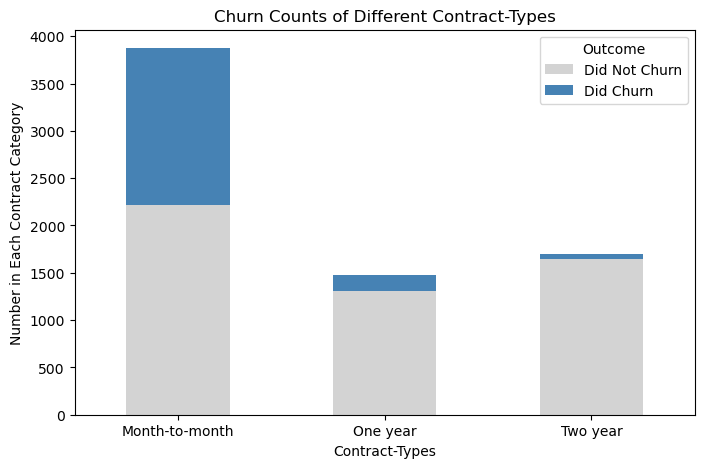

In [56]:
# Write your code here.
contract_churn_counts.plot(
    kind="bar",
    stacked=True,
    color=["lightgray", "steelblue"],
    figsize=(8, 5)
)

plt.title("Churn Counts of Different Contract-Types")
plt.xlabel("Contract-Types")
plt.ylabel("Number in Each Contract Category")
plt.xticks(rotation=0)
plt.legend(["Did Not Churn", "Did Churn"], title="Outcome")
plt.show()

### Visualize the conditional percentages

Make a 100% stacked bar chart from `churn_within_contract`. Use:

- `"lightgray"` for customers who did not churn;
- `"steelblue"` for customers who churned;
- a question-focused title;
- descriptive axis labels;
- horizontal x-axis labels; and
- an audience-friendly legend.


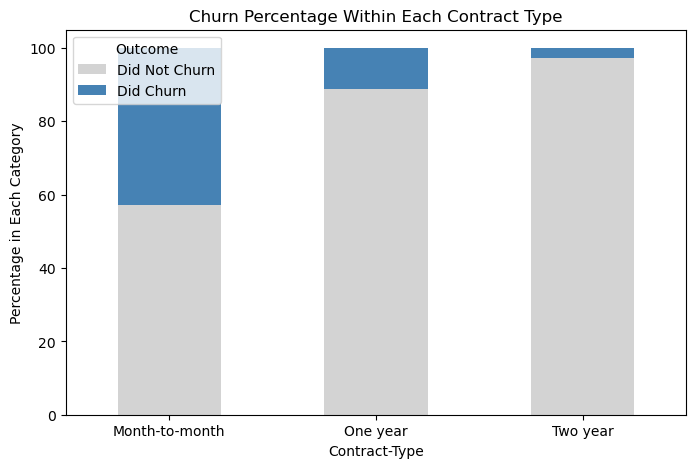

In [57]:
# Write your code here.
churn_within_contract.plot(
    kind="bar",
    stacked=True,
    color=["lightgray", "steelblue"],
    figsize=(8, 5)
)

plt.title("Churn Percentage Within Each Contract Type")
plt.xlabel("Contract-Type")
plt.ylabel("Percentage in Each Category")
plt.xticks(rotation=0)
plt.legend(["Did Not Churn", "Did Churn"], title="Outcome")
plt.show()

**Which chart answers the likelihood question more clearly: counts or conditional percentages? Explain.**

Your answer: The 100% stacked chart does. Since the regular stacked bar chart is utilizing the counts of customers in each contract-type, it's not immediately clear which has more turnover. The 100% stacked bar chart utilizes the conditional percentages, so all contract types are on the same scale, 0-100%, and it's clearly comparable between the three which has more churn.


## Step 6: Conclusion


**What conclusion about contract type and churn is supported by this sample?**

Your answer: The shorter term the contract, the higher likelihood of a churn incident. 


## Step 7: Limitation


**Why does this analysis not prove that changing a customer's contract would cause a change in churn?**

Your answer: This analysis just shows the connection between contract types and churn, not that having a specific contract type would affect a customer's churn decision. A Two-Year who switches to a month-to-month won't necessarily cancel their contract just because they're in a month-to-month contract now. 


# Analysis 2: Is churn related to payment method?

Apply the same workflow to a second pair of categorical features.


## Step 1: Question


The question is: **Is churn related to payment method?**


## Step 2: Data

Create and display the joint distribution of `payment_method` and `churn` as raw counts. Name it `payment_churn_counts`.

Create and display `payment_churn_counts`.


In [58]:
# Write your code here.
payment_churn_counts = pd.crosstab(customers['payment_method'], customers['churn'])

payment_churn_counts

churn,No,Yes
payment_method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


## Step 3: Operation

Create and display `churn_within_payment`.


In [59]:
# Write your code here.
churn_within_payment = pd.crosstab(customers['payment_method'], customers['churn'], normalize='index')*100

churn_within_payment

churn,No,Yes
payment_method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## Step 4: Check

Display the sum of every row in `churn_within_payment`.


In [60]:
# Write your code here.
churn_within_payment.sum(axis=1)

payment_method
Bank transfer (automatic)    100.0
Credit card (automatic)      100.0
Electronic check             100.0
Mailed check                 100.0
dtype: float64

**Which payment-method group had the greatest observed churn percentage? Report the percentage.**

Your answer: The payment method with the greatest observed churn percentage is 'Electronic Check' with 45.29%

## Step 5: Evidence

Make a 100% stacked bar chart. Choose two readable colors that are different from the `"lightgray"` and `"steelblue"` used in the contract chart. Use the same color consistently for each outcome throughout this chart and include audience-friendly labels.


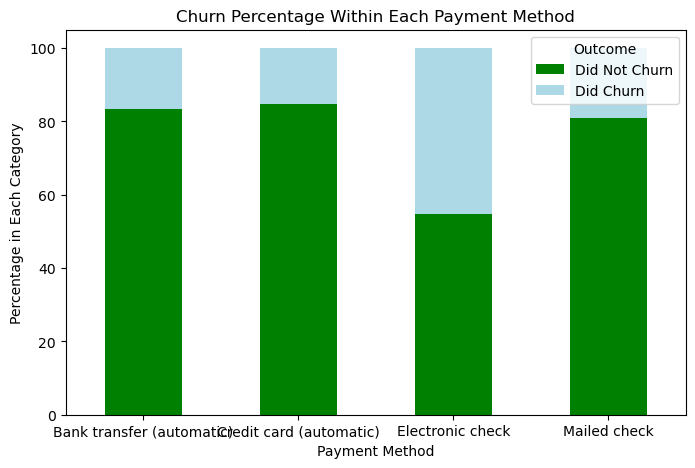

In [61]:
# Write your code here.
churn_within_payment.plot(
    kind="bar",
    stacked=True,
    color=["green", "lightblue"],
    figsize=(8, 5)
)

plt.title("Churn Percentage Within Each Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage in Each Category")
plt.xticks(rotation=0)
plt.legend(["Did Not Churn", "Did Churn"], title="Outcome")
plt.show()

## Step 6: Conclusion


**What conclusion about payment method and churn is supported by the sample? Include the percentage that provides your strongest evidence.**

Your answer: Those who pay with an electronic check are more likely to cancel their contract. This is proven by the churn percentage for that category being 45.29%, compared to the second highest, which is mailed check, with a 19.11% churn percentage.


## Step 7: Limitation


**Why does this analysis not prove that changing a customer's payment method would cause a change in churn?**

Your answer: For the same reason as comparing contract types and churn. It shows a connection between the payment method and churn-likelihood, but changing a customer's payment method doesn't change their habits or intentions.


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that you did not use one.

Your answer: I used the one on Google, in order to see how to get the entire sum of the count for contract_joint_percent. Just a singluar sum() was only giving me the churn summation, that's when I found .sum().sum() would add up all values.


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Use named colors and audience-friendly labels.
- Keep code, figures, and written answers neat and easy to read.
- Distinguish an observed relationship from a causal claim.
- Complete the AI-use reflection.
- Submit the completed notebook by the deadline.
